In [2]:
import radiomana
from radiomana import visualization
from torch.utils.data import ConcatDataset, Subset
import os
import numpy as np

In [3]:
os.environ['DSET_FIOT_HIGHWAY2'] = '/home/rishi/Desktop/TDM201/radiomana/fiot_highway2_f32'

In [4]:
# inspect a sigle sample and label
dataset = radiomana.Highway2Dataset()
psd_sample, label = dataset[0]  # power spectral density + jamming classification

In [5]:
class_labels = dataset.class_labels

In [6]:
loader = radiomana.HighwayDataModule(batch_size=9)
loader.setup()
train = loader.data_train

In [8]:
import torch
from torch.utils.data import DataLoader

freqs_hz = radiomana.bin_frequencies(dataset)

# spectral stats for every sample in train, then grouped by class
centroid, spread, peak, db_std, labels = [], [], [], [], []
for psds, labs in DataLoader(train, batch_size=256, num_workers=8):
    s = radiomana.spectral_stats(psds, freqs_hz)
    centroid.append(s["centroid_hz"] / 1e6)
    spread.append(s["spread_hz"] / 1e6)
    peak.append(s["peak_hz"] / 1e6)
    db_std.append(s["db_std"])
    labels.append(labs)

centroid, spread = torch.cat(centroid), torch.cat(spread)
peak, db_std = torch.cat(peak), torch.cat(db_std)
labels = torch.cat(labels)

header = f"{'class':<28}{'n':>6}{'centroid MHz':>18}{'spread MHz':>18}{'peak':>9}{'dB std':>9}"
print(header)
print("-" * len(header))
for c in range(9):
    m = labels == c
    print(
        f"{class_labels[c] + f' ({c})':<28}{int(m.sum()):>6}"
        f"{centroid[m].mean():>11.3f} ±{centroid[m].std():<6.3f}"
        f"{spread[m].mean():>11.3f} ±{spread[m].std():<6.3f}"
        f"{peak[m].mean():>9.2f}{db_std[m].mean():>9.2f}"
    )
print("-" * len(header))
print(f"{'ALL':<28}{len(labels):>6}{centroid.mean():>11.3f} ±{centroid.std():<6.3f}{spread.mean():>11.3f} ±{spread.std():<6.3f}{'':>9}{db_std.mean():>9.2f}")


class                            n      centroid MHz        spread MHz     peak   dB std
----------------------------------------------------------------------------------------
None (background a) (0)       3773     -5.413 ±2.697      13.180 ±0.676     -6.02     7.59
None (background b) (1)       2074     -2.703 ±4.732      13.850 ±1.294      1.31     7.62
None (background c) (2)       4997      3.348 ±5.370      15.167 ±1.245     13.76     7.68
None (background d) (3)         43      1.030 ±6.395      14.491 ±1.527      8.60     7.71
Chirp, high distance (4)       158     -2.658 ±2.776      11.434 ±1.856      0.00     8.28
Chirp, medium distance (5)     259      0.937 ±1.328       5.560 ±1.984      1.40    13.21
Chirp, small distance (6)      302      0.188 ±2.538       7.014 ±3.829     -1.22    14.79
Cigarette lighter 1 (7)        144     -5.202 ±1.423      13.097 ±0.575     -1.57     7.56
Cigarette lighter 2 (8)        115      3.970 ±1.625      16.163 ±0.312     20.64     7.46
---

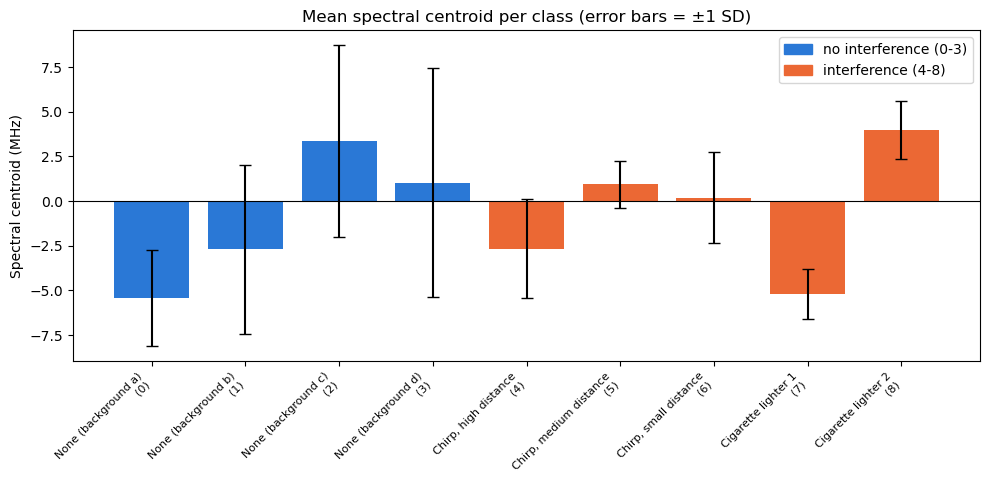

In [9]:
import matplotlib.pyplot as plt

means = [centroid[labels == c].mean().item() for c in range(9)]
errs = [centroid[labels == c].std().item() for c in range(9)]
colors = ["#2a78d6" if c < 4 else "#eb6834" for c in range(9)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(9), means, yerr=errs, capsize=4, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(9))
ax.set_xticklabels([f"{class_labels[c]}\n({c})" for c in range(9)], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Spectral centroid (MHz)")
ax.set_title("Mean spectral centroid per class (error bars = ±1 SD)")

handles = [plt.Rectangle((0, 0), 1, 1, color="#2a78d6"), plt.Rectangle((0, 0), 1, 1, color="#eb6834")]
ax.legend(handles, ["no interference (0-3)", "interference (4-8)"])
plt.tight_layout()
plt.show()


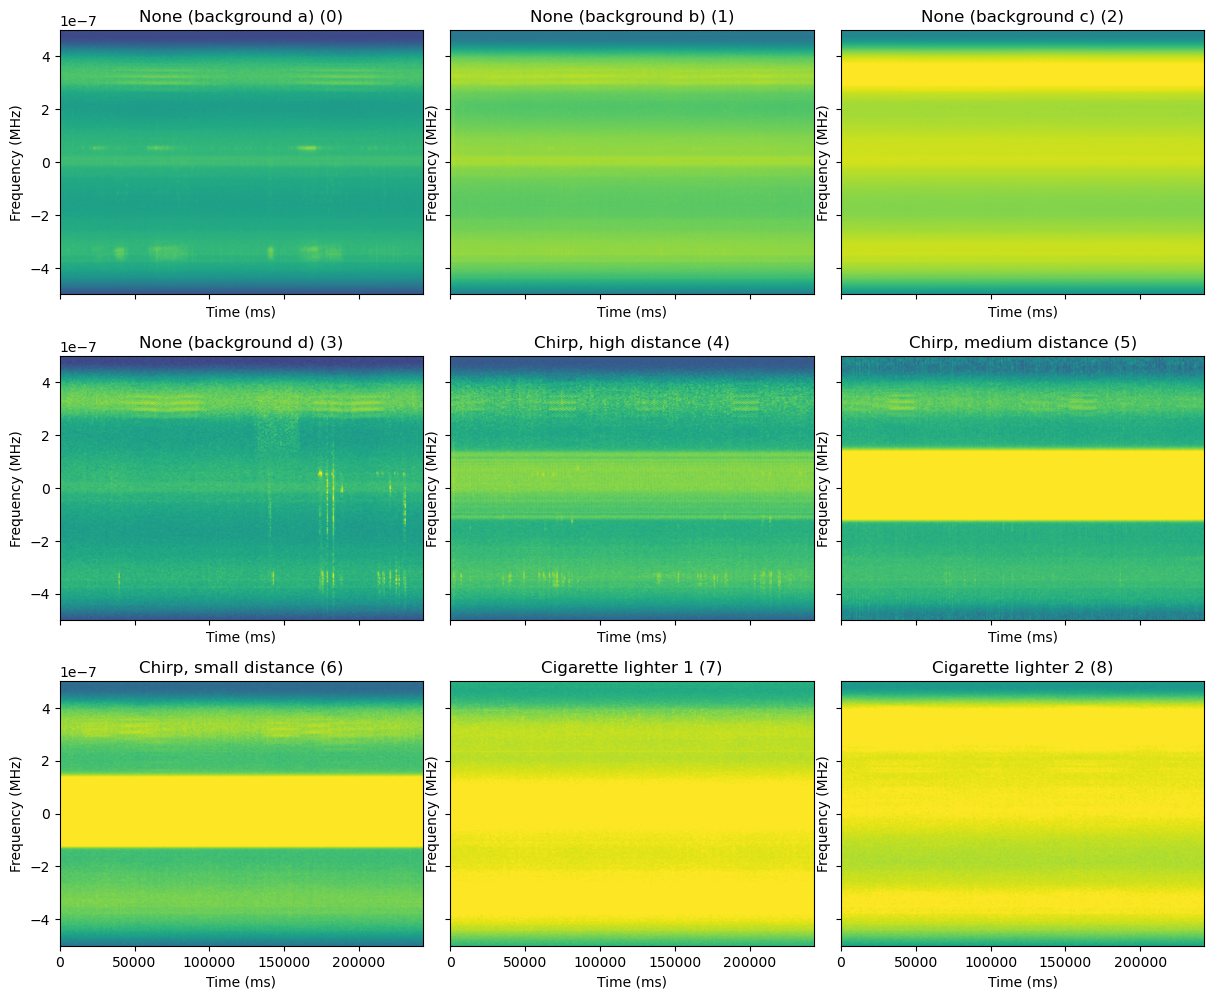

In [81]:
visualization.plot_per_class_average(train)

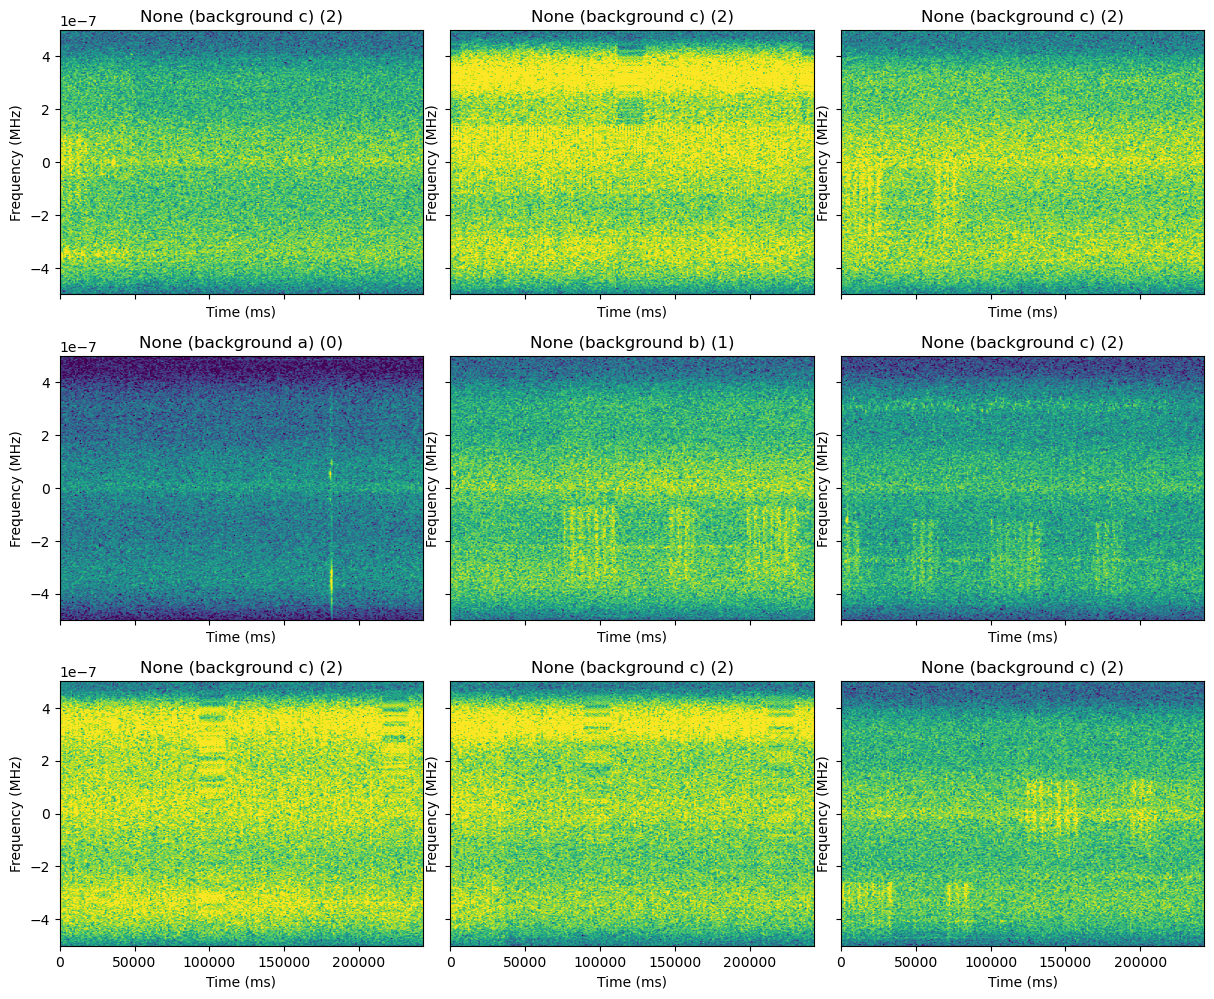

In [ ]:
visualization.plot9(train_batch[0], train_batch[1], class_labels=class_labels)

In [7]:
# inspect a training batch
datamodule = radiomana.HighwayDataModule(batch_size=32, num_workers=4)
datamodule.setup()
train_batch = next(iter(datamodule.train_dataloader()))

In [30]:
train_batch[1]

tensor([2, 2, 2, 0, 1, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 1, 2, 2, 2, 5, 1, 0, 0, 2,
        0, 0, 1, 2, 0, 1, 2, 0])

In [ ]:
import lightning as L
import torch
from radiomana.models import HighwayViTModel

# free anything the previous ViT cell left on the GPU
for name in ("model", "optimizer", "x", "y", "logits", "preds"):
    globals().pop(name, None)
torch.cuda.empty_cache()

# validating on the 1,319-sample val split at the end of the epoch
torch.set_float32_matmul_precision("high")
model = HighwayViTModel()
trainer = L.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
    precision="16-mixed",
    logger=False,
    enable_checkpointing=False,
)
trainer.fit(model, datamodule=datamodule)

# evaluate on the 3,296-sample test split
results = trainer.test(model, datamodule=datamodule)[0]

confmat = model.confmat
class_acc = torch.diagonal(confmat) / confmat.sum(dim=1)
print("\ntest per-class accuracy:")
for cdx, name in enumerate(class_labels):
    print(f"  {cdx} {name:<24s} {class_acc[cdx]:8.1%}   (n={int(confmat[cdx].sum())})")
print(f"\ntest loss: {results['test_loss']:.3f}")
print(f"test f1:   {results['test_f1']:.3f}")
print(f"test acc:  {results['test_acc']:.1%}")


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
/home/rishi/anaconda3/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
│ 1 │ submodel  │ VisionTransformer │ 85.8 M │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343.222                                                                    
Modules in train mode: 153                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7818567752838135     │
│          test_f1          │    0.6107869148254395     │
│         test_loss         │    0.9156325459480286     │
└───────────────────────────┴───────────────────────────┘


test per-class accuracy:
  0 None (background a)         91.2%   (n=1048)
  1 None (background b)         25.9%   (n=576)
  2 None (background c)         91.7%   (n=1388)
  3 None (background d)          0.0%   (n=12)
  4 Chirp, high distance        61.4%   (n=44)
  5 Chirp, medium distance      91.7%   (n=72)
  6 Chirp, small distance       86.9%   (n=84)
  7 Cigarette lighter 1         82.5%   (n=40)
  8 Cigarette lighter 2          0.0%   (n=32)

test loss: 0.916
test f1:   0.611
test acc:  78.2%
